# Pipeline A — Sanity Check Notebook

This notebook does two things:
1. Runs `tile_dataset.py` to prepare the training data
2. Runs a quick smoke test to verify everything is wired correctly before committing to a full training run

**Run this before `train_yolo.py`.** If anything fails here, fix it before training.

## 0. Paths — Set These Once

In [4]:
from pathlib import Path
import sys

# Project root: works when run from notebooks/ or from project root (e.g. nbconvert)
ROOT = Path.cwd() if (Path.cwd() / 'pipeline_A_yolo').is_dir() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

# ── CHANGE THESE TO MATCH YOUR SETUP ────────────────────────────────────────
ANNOTATED_DIR = ROOT / 'data' / 'annotated'   # Roboflow export (untouched)
TILED_DIR     = ROOT / 'data' / 'tiled'       # output of tile_dataset.py
WEIGHTS_DIR   = ROOT / 'outputs' / 'weights'
# ────────────────────────────────────────────────────────────────────────────

DATA_YAML  = ANNOTATED_DIR / 'data.yaml'   # input  → tile_dataset.py reads this
TILED_YAML = TILED_DIR     / 'data.yaml'   # output → train_yolo.py reads this

# Verify annotated dir exists before going further
assert ANNOTATED_DIR.exists(), \
    f"Annotated dir not found: {ANNOTATED_DIR}\nDid you export from Roboflow?"
assert DATA_YAML.exists(), \
    f"data.yaml not found at {DATA_YAML}\nIs this a valid Roboflow export?"

print(f"Annotated dir : {ANNOTATED_DIR.resolve()}")
print(f"Tiled dir     : {TILED_DIR.resolve()}")
print(f"Input yaml    : {DATA_YAML}")
print(f"Output yaml   : {TILED_YAML}")
print("\n✓ Paths look correct")

Annotated dir : /Users/halaabutair/Desktop/Year 4/Image Processing/dendrite-segmentation/data/annotated
Tiled dir     : /Users/halaabutair/Desktop/Year 4/Image Processing/dendrite-segmentation/data/tiled
Input yaml    : /Users/halaabutair/Desktop/Year 4/Image Processing/dendrite-segmentation/data/annotated/data.yaml
Output yaml   : /Users/halaabutair/Desktop/Year 4/Image Processing/dendrite-segmentation/data/tiled/data.yaml

✓ Paths look correct


## 1. Inspect The Raw Annotated Dataset
Before tiling, verify the Roboflow export structure looks right.

In [5]:
import yaml

with open(DATA_YAML) as f:
    data_config = yaml.safe_load(f)

print("data.yaml contents:")
for k, v in data_config.items():
    print(f"  {k}: {v}")

# Roboflow exports may use 'valid' not 'val' — get folder name from data.yaml
print("\nDataset split sizes:")
for split_key in ['train', 'val', 'test']:
    path_val = data_config.get(split_key, f"../{split_key}/images")
    folder = path_val.strip().split('/')[1] if '/' in path_val else split_key
    img_dir = ANNOTATED_DIR / folder / 'images'
    lbl_dir = ANNOTATED_DIR / folder / 'labels'

    if not img_dir.exists():
        print(f"  {split_key:6s}: directory not found — {img_dir}")
        continue

    images = list(img_dir.glob('*.png')) + list(img_dir.glob('*.jpg'))
    labels = list(lbl_dir.glob('*.txt')) if lbl_dir.exists() else []
    annotated = [l for l in labels if l.stat().st_size > 0]

    print(f"  {split_key:6s}: {len(images):3d} images | "
          f"{len(annotated):3d} annotated labels")

    if len(images) != len(labels):
        print(f"  WARNING: image/label count mismatch in {split_key}")

data.yaml contents:
  train: ../train/images
  val: ../valid/images
  test: ../test/images
  nc: 1
  names: ['Dendrite']
  roboflow: {'workspace': 'raghads-workspace-5kpuc', 'project': 'dendrite-segmentation-ao2bh', 'version': 2, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/raghads-workspace-5kpuc/dendrite-segmentation-ao2bh/dataset/2'}

Dataset split sizes:
  train :  12 images |  11 annotated labels
  val   :   3 images |   3 annotated labels
  test  :   5 images |   5 annotated labels


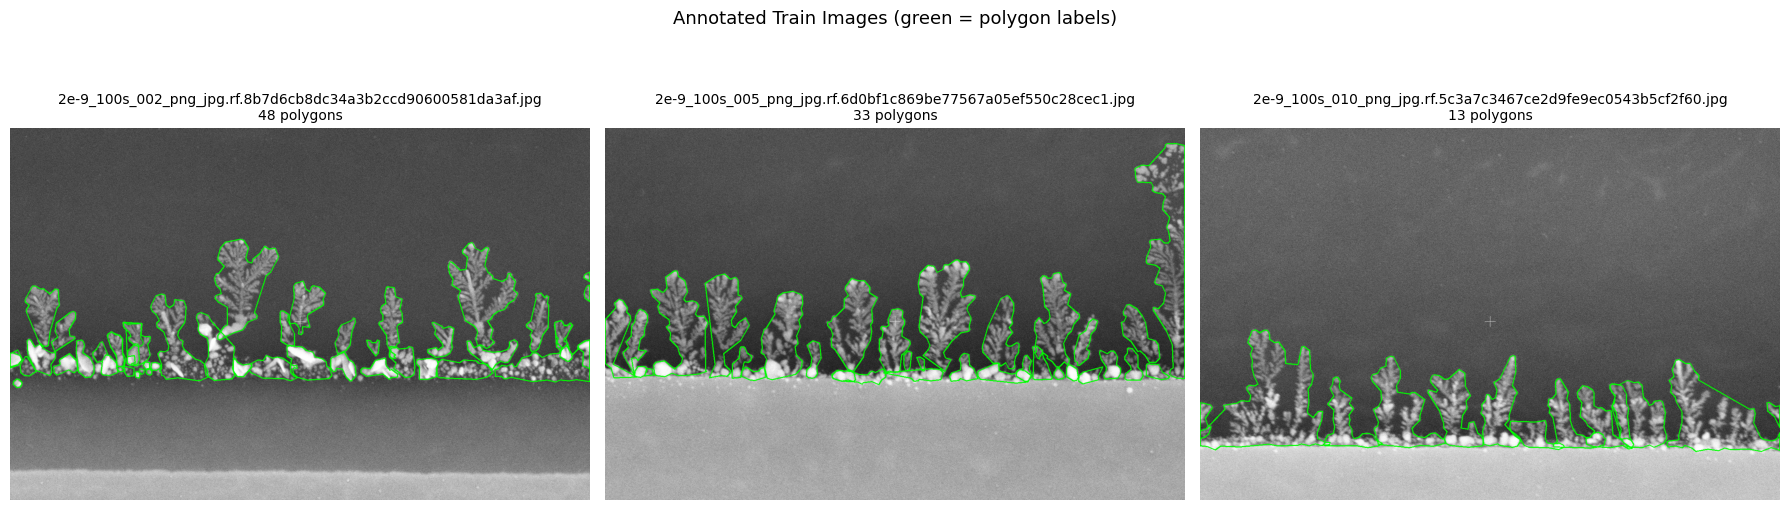

If polygons are aligned with dendrites, annotations look correct
If polygons are misaligned or missing, re-export from Roboflow


In [6]:
# Visualize one annotated image from the train set to confirm
# polygons look correct before tiling
import cv2
import numpy as np
import matplotlib.pyplot as plt

def draw_yolo_polygons(image_path, label_path):
    """Draws YOLO polygon annotations on an image."""
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    h, w = img.shape

    if not Path(label_path).exists() or Path(label_path).stat().st_size == 0:
        return rgb, 0

    n_polygons = 0
    with open(label_path) as f:
        for line in f:
            parts = list(map(float, line.strip().split()))
            coords = parts[1:]  # skip class_id
            pts = []
            for i in range(0, len(coords), 2):
                px = int(coords[i]   * w)
                py = int(coords[i+1] * h)
                pts.append([px, py])
            pts = np.array(pts, dtype=np.int32)
            cv2.polylines(rgb, [pts], isClosed=True,
                          color=(0, 255, 0), thickness=2)
            n_polygons += 1

    return rgb, n_polygons


# Pick first 3 annotated train images (support both .png and .jpg — Roboflow may export as either)
train_img_dir = ANNOTATED_DIR / 'train' / 'images'
train_lbl_dir = ANNOTATED_DIR / 'train' / 'labels'
train_images  = sorted(
    list(train_img_dir.glob('*.png')) + list(train_img_dir.glob('*.jpg'))
)[:3]

if not train_images:
    print("No train images found — check ANNOTATED_DIR/train/images")
else:
    n_show = max(1, len(train_images))  # matplotlib needs at least 1 column
    fig, axes = plt.subplots(1, n_show, figsize=(18, 6))
    if n_show == 1:
        axes = [axes]

    for ax, img_path in zip(axes, train_images):
        lbl_path = train_lbl_dir / (img_path.stem + '.txt')
        annotated_img, n = draw_yolo_polygons(img_path, lbl_path)
        ax.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{img_path.name}\n{n} polygons", fontsize=10)
        ax.axis('off')

    plt.suptitle('Annotated Train Images (green = polygon labels)', fontsize=13)
    plt.tight_layout()
    plt.show()
    print("If polygons are aligned with dendrites, annotations look correct")
    print("If polygons are misaligned or missing, re-export from Roboflow")

## 2. Run tile_dataset.py
Tiles only the train split. Val and test are copied as-is.

In [7]:
# Ensure project root is on path
import sys
from pathlib import Path
_candidates = [Path.cwd(), Path.cwd().parent, Path.cwd() / "notebooks" / ".."]
_project_root = next((p.resolve() for p in _candidates if (p.resolve() / "pipeline_A_yolo").is_dir()), None)
if _project_root and str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

from pipeline_A_yolo.tile_dataset import tile_dataset

# ── TILING PARAMETERS ───────────────────────────────────────────────────────
TILE_SIZE = 640
OVERLAP   = 0.2
# ────────────────────────────────────────────────────────────────────────────

tile_dataset(
    input_dir=str(ANNOTATED_DIR),
    output_dir=str(TILED_DIR),
    tile_size=TILE_SIZE,
    overlap=OVERLAP
)

STEP 1: Tiling train set
  2e-9_100s_002_png_jpg.rf.8b7d6cb8dc34a3b2ccd90600581da3af.jpg → 6 tiles
  2e-9_100s_005_png_jpg.rf.6d0bf1c869be77567a05ef550c28cec1.jpg → 6 tiles
  2e-9_100s_010_png_jpg.rf.5c3a7c3467ce2d9fe9ec0543b5cf2f60.jpg → 6 tiles
  2e-9_100s_014_png_jpg.rf.451a6c20e15bde944e140c3bf0573223.jpg → 6 tiles
  70nm_diameter_100nm_pitch_019_png_jpg.rf.548e9d496b14d35d10083db131ca50f2.jpg → 6 tiles
  70nm_diameter_100nm_pitch_022_png_jpg.rf.24a2db3beace5af7c53bf206c0f49920.jpg → 6 tiles
  70nm_diameter_100nm_pitch_023_png_jpg.rf.613a0fbc84a30fc23c8ff9ce03d7330d.jpg → 6 tiles
  70nm_diameter_100nm_pitch_024_png_jpg.rf.25bf3da777218bcc535ed4fbbfba654d.jpg → 6 tiles
  70nm_diameter_100nm_pitch_025_png_jpg.rf.9b92f0440b86fba445516622ffd7ba1a.jpg → 6 tiles
  70nm_diameter_100nm_pitch_027_png_jpg.rf.504dc38caed2485e90cf2955cb28352e.jpg → 6 tiles
  Ag_2_e-9_016_png_jpg.rf.28258881cd3248f46d3faba0964a53f2.jpg → 6 tiles
  Ag_2e-9_001_png_jpg.rf.2792e4d7068ad99f6525ec4c28e2beb3.jpg → 2 

## 3. Verify Tiled Dataset Structure
Check that tile_dataset.py produced the expected output.

In [8]:
# Count files in each split of the tiled dataset
print("Tiled dataset structure:")
print(f"  {'Split':8s} {'Images':>8s} {'Labels':>8s} {'Annotated':>10s}")
print(f"  {'─'*8} {'─'*8} {'─'*8} {'─'*10}")

for split in ['train', 'val', 'test']:
    img_dir = TILED_DIR / split / 'images'
    lbl_dir = TILED_DIR / split / 'labels'

    if not img_dir.exists():
        print(f"  {split:8s} NOT FOUND")
        continue

    images    = list(img_dir.glob('*.png')) + list(img_dir.glob('*.jpg'))
    labels    = list(lbl_dir.glob('*.txt')) if lbl_dir.exists() else []
    annotated = [l for l in labels if l.stat().st_size > 0]

    tiled_note = '← tiled' if split == 'train' else '← full images'
    print(f"  {split:8s} {len(images):8d} {len(labels):8d} "
          f"{len(annotated):10d}  {tiled_note}")

print()

# Verify tiled yaml was created
assert TILED_YAML.exists(), f"TILED_YAML not found: {TILED_YAML}"
with open(TILED_YAML) as f:
    tiled_config = yaml.safe_load(f)
print("Tiled data.yaml:")
for k, v in tiled_config.items():
    print(f"  {k}: {v}")

Tiled dataset structure:
  Split      Images   Labels  Annotated
  ──────── ──────── ──────── ──────────
  train          68       68         58  ← tiled
  val             3        3          3  ← full images
  test            5        5          5  ← full images

Tiled data.yaml:
  names: ['Dendrite']
  nc: 1
  path: /Users/halaabutair/Desktop/Year 4/Image Processing/dendrite-segmentation/data/tiled
  roboflow: {'license': 'CC BY 4.0', 'project': 'dendrite-segmentation-ao2bh', 'url': 'https://universe.roboflow.com/raghads-workspace-5kpuc/dendrite-segmentation-ao2bh/dataset/2', 'version': 2, 'workspace': 'raghads-workspace-5kpuc'}
  test: test/images
  train: train/images
  val: val/images


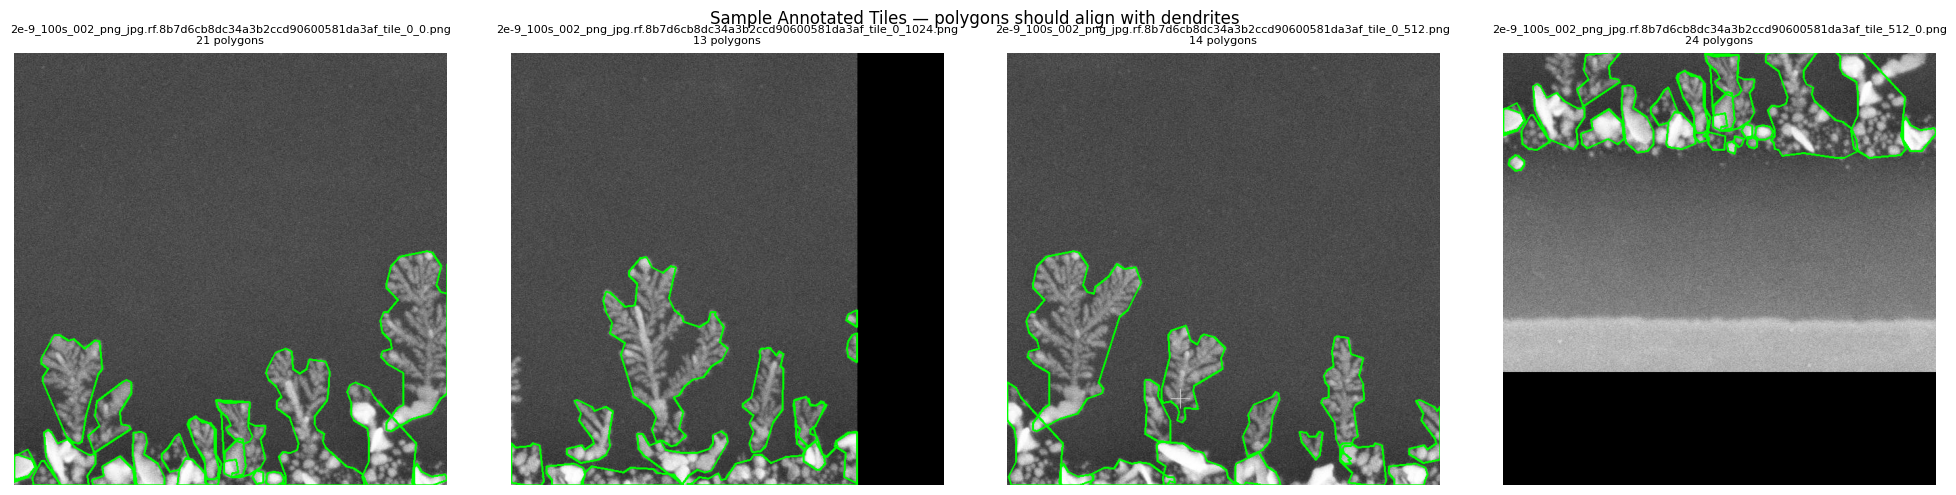

Showing 4 annotated tiles
  Check: are the green polygons sitting on the dendrites?
  If yes → tiling + coordinate adjustment is correct
  If no  → there is a bug in tile_dataset.py coordinate math


In [9]:
# Visually inspect a few tiles — do they look right?
# You should see: small 640x640 crops with parts of dendrites visible
# and green polygons aligned to them

tiled_img_dir = TILED_DIR / 'train' / 'images'
tiled_lbl_dir = TILED_DIR / 'train' / 'labels'

# Pick tiles that have annotations (non-empty label files); support .png and .jpg
all_tiles = list(tiled_img_dir.glob('*.png')) + list(tiled_img_dir.glob('*.jpg'))
annotated_tiles = sorted([
    p for p in all_tiles
    if (tiled_lbl_dir / (p.stem + '.txt')).exists()
    and (tiled_lbl_dir / (p.stem + '.txt')).stat().st_size > 0
])[:4]

if not annotated_tiles:
    print("⚠ No annotated tiles found — check tile_dataset.py output")
else:
    fig, axes = plt.subplots(1, len(annotated_tiles), figsize=(20, 5))
    if len(annotated_tiles) == 1:
        axes = [axes]

    for ax, tile_path in zip(axes, annotated_tiles):
        lbl_path = tiled_lbl_dir / (tile_path.stem + '.txt')
        annotated_tile, n = draw_yolo_polygons(tile_path, lbl_path)
        ax.imshow(cv2.cvtColor(annotated_tile, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{tile_path.name}\n{n} polygons", fontsize=8)
        ax.axis('off')

    plt.suptitle('Sample Annotated Tiles — polygons should align with dendrites',
                 fontsize=12)
    plt.tight_layout()
    plt.show()
    print(f"Showing {len(annotated_tiles)} annotated tiles")
    print("  Check: are the green polygons sitting on the dendrites?")
    print("  If yes → tiling + coordinate adjustment is correct")
    print("  If no  → there is a bug in tile_dataset.py coordinate math")

## 4. Smoke Test — 3-Epoch Mini Training Run
Train for just 3 epochs on a tiny subset to verify the full training
pipeline works end-to-end before committing to 100 epochs.

**This is not real training** — 3 epochs produces a useless model.
The only question we're answering is: does the code run without crashing?

In [10]:
from ultralytics import YOLO

# ── SMOKE TEST PARAMETERS — keep epochs very low ────────────────────────────
SMOKE_MODEL  = 'yolo11n-seg.pt'   # nano = fastest to download + run
SMOKE_EPOCHS = 3
SMOKE_IMGSZ  = 640
# ────────────────────────────────────────────────────────────────────────────

print(f"Loading model: {SMOKE_MODEL}")
print("(Will auto-download if not cached — ~6MB for nano)\n")

smoke_model = YOLO(SMOKE_MODEL)
print("✓ Model loaded")

Loading model: yolo11n-seg.pt
(Will auto-download if not cached — ~6MB for nano)

✓ Model loaded


In [11]:
from datetime import datetime

smoke_run_name = f'smoke_test_{datetime.now().strftime("%H%M%S")}'

print(f"Starting {SMOKE_EPOCHS}-epoch smoke test...")
print(f"Run name: {smoke_run_name}")
print("Expected duration: 1-5 minutes depending on hardware\n")

smoke_results = smoke_model.train(
    data=str(TILED_YAML),
    epochs=SMOKE_EPOCHS,
    imgsz=SMOKE_IMGSZ,
    batch=-1,              # auto batch size
    project=str(WEIGHTS_DIR),
    name=smoke_run_name,
    optimizer='AdamW',
    lr0=0.001,
    hsv_h=0.0,             # no color aug (SEM = grayscale)
    hsv_s=0.0,
    hsv_v=0.3,
    fliplr=0.5,
    mosaic=0.0,
    plots=False,           # skip plots for smoke test
    verbose=True,
    exist_ok=True
)

print("\n✓ Smoke test training completed without errors")

Starting 3-epoch smoke test...
Run name: smoke_test_214604
Expected duration: 1-5 minutes depending on hardware

New https://pypi.org/project/ultralytics/8.4.21 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.18 🚀 Python-3.14.2 torch-2.10.0 CPU (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/halaabutair/Desktop/Year 4/Image Processing/dendrite-segmentation/data/tiled/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None,

In [12]:
# Verify the weights file was actually saved
smoke_run_dir = WEIGHTS_DIR / smoke_run_name
smoke_weights = smoke_run_dir / 'weights' / 'best.pt'

assert smoke_weights.exists(), \
    f"best.pt not found at {smoke_weights} — training may have crashed silently"

size_mb = smoke_weights.stat().st_size / 1e6
print(f"✓ Weights saved: {smoke_weights}  ({size_mb:.1f} MB)")

✓ Weights saved: /Users/halaabutair/Desktop/Year 4/Image Processing/dendrite-segmentation/outputs/weights/smoke_test_214604/weights/best.pt  (6.0 MB)


## 5. Smoke Test — Inference
Run the smoke model on one val image to confirm predict.py works end-to-end.
The mask quality will be terrible (3 epochs) — that's expected and irrelevant.
We're only checking that inference runs without errors.

In [13]:
import sys
sys.path.append('..')
from pipeline_A_yolo.predict import predict_single_image

# Pick one val image for the inference check
val_img_dir = TILED_DIR / 'val' / 'images'
val_images = sorted(
    list(val_img_dir.glob('*.png')) + list(val_img_dir.glob('*.jpg'))
)
assert val_images, "No val images found — check tiled dataset"

test_image = val_images[0]
print(f"Running inference on: {test_image.name}")

# Load the smoke test weights
inference_model = YOLO(str(smoke_weights))

mask = predict_single_image(
    model=inference_model,
    image_path=str(test_image),
    conf_threshold=0.25,
    iou_threshold=0.45
)

print(f"✓ Inference ran successfully")
print(f"  Output mask shape : {mask.shape}")
print(f"  Unique values     : {np.unique(mask)}  (should be [0] or [0 255])")
print(f"  Dendrite coverage : {(mask > 0).mean()*100:.1f}%")
print(f"  (coverage will be low/zero after only {SMOKE_EPOCHS} epochs — this is normal)")

Running inference on: 70nm_diameter_100nm_pitch_026_png_jpg.rf.dd84f75e09ab0f739eca9425797a63c1.jpg
✓ Inference ran successfully
  Output mask shape : (985, 1536)
  Unique values     : [0]  (should be [0] or [0 255])
  Dendrite coverage : 0.0%
  (coverage will be low/zero after only 3 epochs — this is normal)


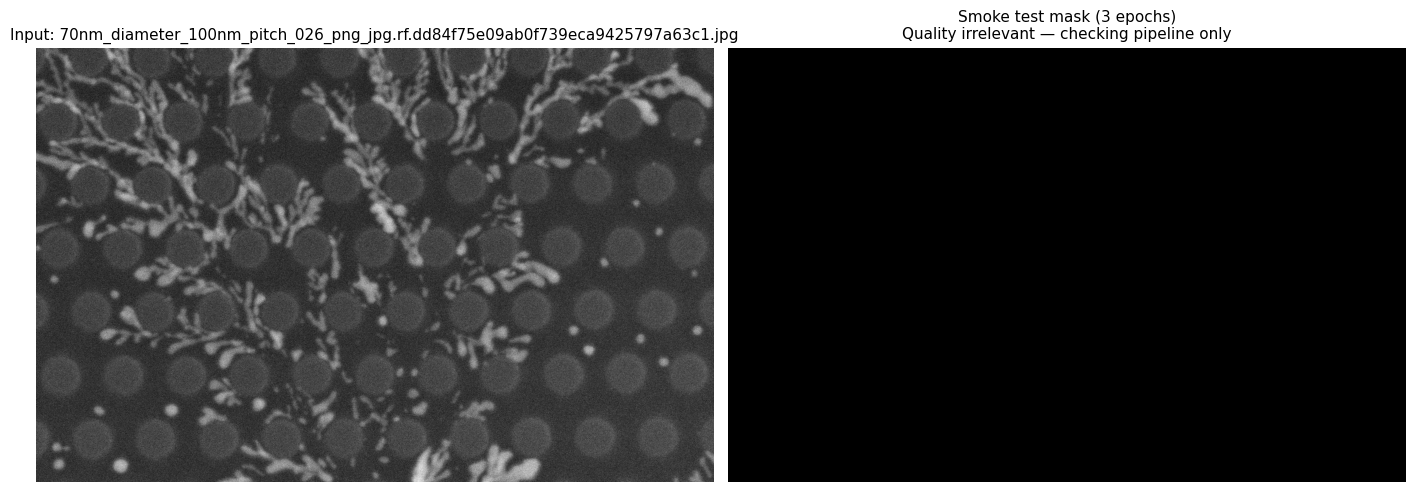

In [14]:
# Show the result — even if the mask is empty/wrong, the pipeline worked
original = cv2.imread(str(test_image), cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(original, cmap='gray')
axes[0].set_title(f'Input: {test_image.name}', fontsize=11)
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title(f'Smoke test mask ({SMOKE_EPOCHS} epochs)\n'
                   'Quality irrelevant — checking pipeline only', fontsize=11)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 6. Summary & Next Steps

In [15]:
print("=" * 55)
print("SANITY CHECK SUMMARY")
print("=" * 55)

checks = [
    (DATA_YAML.exists(),                     "Roboflow export found"),
    (TILED_YAML.exists(),                    "Tiled dataset created"),
    ((TILED_DIR/'train'/'images').exists(),  "Train tiles exist"),
    ((TILED_DIR/'val'/'images').exists(),    "Val images copied (full)"),
    ((TILED_DIR/'test'/'images').exists(),   "Test images copied (full)"),
    (smoke_weights.exists(),                 "Training produced weights"),
    (mask is not None,                       "Inference ran successfully"),
]

all_passed = True
for passed, label in checks:
    icon = "✓" if passed else "✗"
    print(f"  {icon}  {label}")
    if not passed:
        all_passed = False

print()
if all_passed:
    print("All checks passed — ready for full training.")
    print()
    print("Next step:")
    print(f"  python train_yolo.py --data {TILED_YAML} --epochs 100")
else:
    print("Some checks failed — fix the issues above before training.")

SANITY CHECK SUMMARY
  ✓  Roboflow export found
  ✓  Tiled dataset created
  ✓  Train tiles exist
  ✓  Val images copied (full)
  ✓  Test images copied (full)
  ✓  Training produced weights
  ✓  Inference ran successfully

All checks passed — ready for full training.

Next step:
  python train_yolo.py --data /Users/halaabutair/Desktop/Year 4/Image Processing/dendrite-segmentation/data/tiled/data.yaml --epochs 100
